# 🔥 PyTorch tutorial: **Fully-Connected (Dense) Neural Networks** 

## Table of Contents
- [Theory](#theory)
    - [Fully-connected Neural Networks](#fc_l)
    - [Activation Functions](#act)
    - [Optimizers](#opts)
    - [Losses](#loss)
    - [Training Flow](#clsf)
- [Python](#python)
- [PyTorch](#torch)
- [Bulding and Training NNs](#btnn)
    - [The XOR problem](#xor)
    - [Income / Socio-economic Prediction](#income)

## 📚 **Theory** <a class="anchor" id="theory"></a>

### **Fully-connected Neural Networks** <a class="anchor" id="fc_l"></a>

A **fully-connected neural network**, also known as a **dense neural network** is a fundamental type of artificial neural network. It is composed of layers of interconnected nodes, where each node in one layer is connected to every node in the next layer. The basic building block of a fully-connected neural network is the **fully-connected layer**.

#### **Fully-Connected Layer**

A fully-connected layer can be viewed as a function $f: \mathbb{R}^{N_{\text{in}}} \rightarrow \mathbb{R}^{N_{\text{out}}}$ parametrized by a matrix $ \mathbf{W} \in \mathbb{R}^{N_{\text{out}} \times N_{\text{in}}}$ and vector $ b \in \mathbb{R}^{N_{\text{out}}}$.

Mathematically, the output $ y \in \mathbb{R}^{N_{\text{out}}}$ of a fully-connected layer, given input vector $x \in \mathbb{R}^{N_{\text{in}}}$, can be expressed as: 

$$ y = f(x) = \mathbf{W}x + b $$

<div style="text-align: center;">
  <img src="imgs/fcl.png" alt="description" width="600"/>
  <figcaption>Diagram of a fully-connected layer</figcaption>
</div>

The weight matrix ($ \mathbf{W} $) encapsulates the connections between neurons in the current layer and the next layer. Each element $ w_{ij} $ in ($ \mathbf{W} $) corresponds to the weight of the connection between the $j^{th}$ neuron in the current layer and the $i^{th}$ neuron in the next layer.

The bias vector ( $b$ ) is added to the weighted sum to introduce an offset, allowing the model to learn translations, while also helping in handling non-zero inputs and enhancing expressiveness.

#### *Are such structures still relevant?*

**Yep.**

They are part of current LLM/multimodal architectures:

<div style="text-align: center;">
  <img src="imgs/gpt_linear.png" alt="description" width="800"/>
  <figcaption>Original Architecture of GPT.</figcaption>
</div>

<div style="text-align: center;">
  <img src="imgs/blip.png" alt="description" width="800"/>
  <figcaption>Architecture of <a href="https://arxiv.org/pdf/2301.12597">BLIP-2</a>, for vision-to-language applications.</figcaption>
</div>

### **Activation Functions** <a class="anchor" id="act"></a>

Activation functions play a crucial role in neural networks by introducing non-linearities to the model. These non-linearities enable neural networks to learn and represent complex relationships in data.

Some common activation functions:

- **Sigmoid (Logistic) Function**: $$ \sigma(x) = {{1} \over {1 + e^{-x}}}, \,\, \sigma: \mathbb{R} \rightarrow \mathbb [0, 1] $$ Commonly used in the output layer of binary classification models. Vanishing gradient problems in deep networks.

- **Hyperbolic Tangent (tanh)**: $$ \sigma(x) = {{e^x - e^{-x}} \over {e^x + e^{-x}}}, \,\, \sigma: \mathbb{R} \rightarrow \mathbb [-1, 1] $$ Outputs values in the range (-1, 1). Similar to the sigmoid but with a symmetric range. May help mitigate issues related to vanishing gradients.

- **Rectified Linear Unit (ReLU)**: $$ \sigma(x) = \max(0, x), \,\, \sigma: \mathbb{R} \rightarrow \mathbb [0, \infty] $$ Addresses the vanishing gradient problem compared to traditional sigmoid and tanh. Widely used due to its simplicity, effectiveness and computational efficiency, along with its other variants: Leaky ReLU, PReLU, ELU, etc.

- **Softmax**: for a vector $z = (z_1, \dots, z_n)$, the outputs $y = (y_1, \dots, y_n)$ are defined as follows: $$ y_i = {{e^{z_i}} \over {\sum_{j=1}^n e^{z_j}}}, \,\, y_i \in [0, 1], \,\,\sum_{i=1}^n y_i = 1$$ 

The *Softmax* is mostly used as a final processing applied on the output vector to transform its contents into a *[discrete probability distribution](https://en.wikipedia.org/wiki/Probability_mass_function)*, in classification tasks, or to compute weighting values in the *[attention mechanism](https://proceedings.neurips.cc/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)*.

### Neural Network Structure <a class="anchor" id="act"></a>

The function computed by a multi-layer fully-connected neural network with $m$ layers, represented by fully connected operators $ \{f_i\}_{i=1}^{m} $ and non-linear activation operators $ \{\sigma_i\}_{i=1}^{m-1} $, can be written as:

$$ T(x) = (f_m \circ \sigma_{m-1} \circ f_{m-1} \circ \dots \circ \sigma_1 \circ f_1 ) (x)$$ 
which represents an alternation between linear and non-linear operations.

**For $\sigma = I_d = diag([1, \dots, 1])$, the above function can be reduced to a single fully-connected layer $\rightarrow$ therefore a single linear layer is equivalent with multiple stacked linear layers.**

### **Optimizers** <a class="anchor" id="opts"></a>

Optimization in neural networks refers to the process of adjusting the model's parameters during training to minimize some "error" function, taylored for the task at hand. The objective is to find the optimal set of weights and biases that allow the neural network to make accurate predictions on unseen data. The most common class of optimization algorithms are *gradient-based methods*.

**Stochastic Gradient Descent (SGD)** is a fundamental optimization algorithm widely used for training neural networks. It operates by iteratively updating the model parameters based on the gradients of the loss with respect to those parameters. 

```python
def sgd(loss, start_point, learning_rate, n_iterations):
    current_point = start_point
    # iteratively refine the optimum estimate    
    for i in range(n_iterations):
        # set the function to the current estimated optimum
        loss.update(current_point)
        # compute gradient of function w.r.t the current point
        current_gradient = loss.gradient(current_point)
        # update current optimum estimate
        current_point = current_point - learning_rate * current_gradient

    return current_point
```

In the above, the gradient w.r.t. to the input point is used to follow the direction of descent (or ascent, based on the `sign`). In the neural network case, the input data is fixed, and we're trying to find those weights and biases which best fit to our data. Therefore, we are learning the **input-output** function that minimizes the `loss`, given the desired input and output variables.

Some notable optimization algorithms, other than SGD, are: [Adam](https://arxiv.org/pdf/1412.6980.pdf%5D), [RMSprop](https://www.cs.toronto.edu/~hinton/coursera/lecture6/lec6.pdf), [LBFGS](https://en.wikipedia.org/wiki/Limited-memory_BFGS), [Nadam](https://cs229.stanford.edu/proj2015/054_report.pdf)

There are also algorithms that try to optimize the model's hyperparameters (e.g. number of layers, number of neurons): [Hyperband](https://www.jmlr.org/papers/volume18/16-558/16-558.pdf), [Progressive NAS](http://openaccess.thecvf.com/content_ECCV_2018/papers/Chenxi_Liu_Progressive_Neural_Architecture_ECCV_2018_paper.pdf) 

### **Loss (Error/Cost) Functions** <a class="anchor" id="loss"></a>

Loss functions quantify the difference between predicted values and actual target values during the training of machine learning models. Different tasks and model types require specific loss functions.

Given $N$ target outputs $\{y_i\}_{i=1}^N$ and predicted outputs $\{\hat{y_i}\}_{i=1}^m$, some common loss functions include:

- Root Mean Squared Error (RMSE) - regression loss function used when predicting continuous values:
  $$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} ||y_i - \hat{y_i}||_2$$
  here $y_i$ and $\hat{y_i}$ could be vectors of any dimension.
  
- Hinge Loss - commonly used in Support Vector Machines (SVMs) for binary classification, it penalizes misclassified samples linearly and encourages correct classification with a margin:
  $$\text{HingeLoss} = \sum_{i=1}^{N} \max(0, 1 - y_i \cdot \hat{y_i})$$
  For binary classification, $y_i$ and $\hat{y_i}$ are scalars in $[-1, 1]$
- Cross-Entropy Loss - commonly used in multiclass-classification problems, it measures the performance of a classification model whose output is a discrete probability vector over all possible classes:
  $$\text{CrossEntropyLoss} = -\sum_{i=1}^{N} \sum_{c=1}^C y_i[c] \log(\hat{y_i}[c])$$
  In this context, $y_i \in \mathbb{R}^C$ is a *one-hot* vector with a single entry of 1 and 0 elsewhere, and $\hat{y_i[c]}$ represents the probability assigned by the neural network for the $i^{th}$ input example to be of class $c$.

In general, the cost will be parametrized as $L(W, b, X, Y)$, for some dataset $(X, Y)$ and network parameters $W = \{W_i\}_{i=1}^m, b=\{b_i\}_{i=1}^m$.

### **Training Flow** <a class="anchor" id="clsf"></a>

<div style="text-align: center;">
  <img src="imgs/train_flow.png" alt="description" width="1000"/>
</div>

Given a neural network built by a sequence of linear layers ${f_i}_{i=1}^m$, and a dataset with input features $X \in \mathbb{R}^{N \times D}$ ($N$ data vectors, with $D$ elements) and corresponding targets $Y$, the goal is to minimize a chosen loss function $L(W, b, X, Y)$.

1. **Initialization:**
   - Initialize the weights $W_k$ and biases $b_k$ of each layer $f_k$.
2. **Forward Pass:**
   - For each input $x_i$ (or batch of inputs $B = \{x_j\}_{j=1}^{\text{batch size}}$) in the dataset:
     - Compute the predicted output $y_i$ using the current weights and biases.
       $$y_i = f_m \circ \sigma_{m-1} \circ f_{m-1} \circ \dots \circ \sigma_1 \circ f_1 (x_i)$$
     - Calculate the loss $L$ between the predicted outputs and the actual targets:
       $$L(W, b, X, Y) = \frac{1}{N} \sum_{i=1}^{N} \text{loss}(y_i, y_i^{\text{true}})$$
       where $\text{loss}$ is the chosen error function (e.g., mean squared error, cross-entropy).
     - Compute the gradient of the loss with respect to the weights and biases using the chain rule:
       $$\frac{\partial L}{\partial W_i} = \frac{\partial L}{\partial f_m} \frac{\partial f_m}{\partial \sigma_{m-1}} \dots \frac{\partial \sigma_i}{\partial f_i} \frac{\partial f_i}{\partial W_i}, \forall i \in \{1, \dots, m-1\} \,\, (\text{similar for} \, b_i)$$
     - Update the weights and biases in the opposite direction of the gradients to minimize the loss:
       $$W_i \leftarrow W_i - \alpha \frac{\partial L}{\partial W_i}; \, b_i \leftarrow b_i - \alpha \frac{\partial L}{\partial b_i}$$
       where $\alpha$ is the learning rate.	

3. **Repeat:** for a number of epochs $E$, or until some stopping criterion is achieved. 

## **Python** <a class="anchor" id="python"></a>

Python is a high-level, versatile programming language widely used in various domains, including data science and artificial intelligence. Its simplicity, readability, and extensive community support make it an excellent choice for beginners. In the context of out lab, Python will be the primary language for implementing and experimenting with neural networks.

**Python Packages** extend the core functionality of Python and provide specialized tools for various tasks. To import a package, you typically use the import keyword followed by the name of the package:
```python
import numpy as np
from utils import CustomFC
```

In the above example, `np` is an alias for `NumPy`. It's a common convention to use short and recognizable aliases to make the code more concise. We can install packages right here using the following:

In [1]:
!pip install matplotlib

DEPRECATION: geotiff 0.2.7 has a non-standard dependency specifier zarr>=2.10.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of geotiff or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: matlabengineforpython R2021b has a non-standard version number. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of matlabengineforpython or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Resources for learning Python**:
- [Python for Everybody](https://www.py4e.com/)
- [Introduction to Computer Science and Programming Using Python](https://www.edx.org/learn/computer-science/massachusetts-institute-of-technology-introduction-to-computer-science-and-programming-using-python)
- [Codeacademy Python 3](https://www.codecademy.com/learn/learn-python-3)
- [CS231n Python Tutorial With Google Colab](https://colab.research.google.com/github/cs231n/cs231n.github.io/blob/master/python-colab.ipynb#scrollTo=dzNng6vCL9eP)

## **PyTorch - Basics** <a class="anchor" id="torch"></a>

PyTorch is an open-source deep learning library developed by Facebook's AI Research lab ([FAIR](https://ai.meta.com/research/)). It is widely used for building and training neural networks. Some key features are:
- Tensor Computation - efficient and accelerated numerical computations using *multi-dimensional arrays*
- Automatic Differentiation - computation of gradients during training, less error-prone
- Eager Execution - operations are executed immediately as they are called, allowing for interactive development

[[Official Docs]](https://docs.pytorch.org/docs/stable/index.html). To look for a specific version that will work with your CUDA/cuDNN, search [here](https://pytorch.org/get-started/previous-versions/).

### What is a *Tensor*?

<div style="text-align: center;">
  <img src="imgs/tensors.png" alt="description" width="800"/>
  <figcaption><a href="https://kindsonthegenius.com/blog/simple-explanation-of-tensors-1-an-introduction/">Reference</a></figcaption>
</div>

A m-dimensional tensor is the mathematical object defined as $X \in \mathbb{R}^{N_1 \times N_2 \times \dots \times N_m}$, where $N_i \in \mathbb{N}^*$ represents the number of elements in the $i^{th}$ dimension. For example, an RGB image would be represented as a 3D tensor $X \in \mathbb{R}^{H \times W \times 3}$, where the first 2 dimensions represent the spatial width and height, while the last corresponds to the number of color channels.

### Basic Tensor Operations

##### Creating empty tensors:

In [2]:
import torch

x = torch.empty(3)
print("1D tensor: \n", x)

x = torch.empty(3, 2)
print("2D tensor: \n", x)

x = torch.empty(3, 2, 4)
print("3D tensor: \n", x)

1D tensor: 
 tensor([-3.2224e+09,  1.0762e-42,  0.0000e+00])
2D tensor: 
 tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])
3D tensor: 
 tensor([[[-3.2884e+09,  1.0762e-42,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]]])


##### Creating valued tensors:

In [3]:
import numpy as np

print("First valued tensor:")
x = torch.Tensor(
    [[1, 2, 3],
     [4, 5, 6]]
)
print(x)

print("Second valued tensor:")
random_values = np.random.uniform(-3, 3, (2, 5))
x = torch.from_numpy(random_values)
print(x)

First valued tensor:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Second valued tensor:
tensor([[-0.1371, -1.8539, -0.3779, -1.8952,  2.1635],
        [ 0.7471, -1.6971, -0.5186,  2.3767,  0.8013]], dtype=torch.float64)


##### Element-wise Operations:

In [4]:
x = torch.Tensor(
    [[1, 2, 3],
     [4, 5, 6]]
)

add = x + 3
mul = x * 4
pow = x ** 2

print("Element-wise addition: ")
print(add)
print("Element-wise multiplication: ")
print(mul)
print("Pow:")
print(pow)

Element-wise addition: 
tensor([[4., 5., 6.],
        [7., 8., 9.]])
Element-wise multiplication: 
tensor([[ 4.,  8., 12.],
        [16., 20., 24.]])
Pow:
tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]])


##### Matrix operations:

In [5]:
matrix_a = torch.tensor([[1, 2], [3, 4]])
matrix_b = torch.tensor([[5, 6], [7, 8]])
result_matrix_mul_1 = torch.mm(matrix_a, matrix_b)
result_matrix_mul_2 = matrix_a @ matrix_b
result_matrix_add = matrix_a + matrix_b

print("Mul: \n", result_matrix_mul_1, "\n", result_matrix_mul_2)
print("Add: \n", result_matrix_add)

Mul: 
 tensor([[19, 22],
        [43, 50]]) 
 tensor([[19, 22],
        [43, 50]])
Add: 
 tensor([[ 6,  8],
        [10, 12]])


In [6]:
matrix_a = torch.ones(3, 4, 5)
matrix_b = torch.ones(3, 5, 6)

torch.bmm(matrix_a, matrix_b).shape

torch.Size([3, 4, 6])

##### Reshaping Tensors:

In [7]:
original_tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float)
reshaped_tensor_1 = original_tensor.view(3, 2)
reshaped_tensor_2 = original_tensor.view(1, 6)

print(reshaped_tensor_1, reshaped_tensor_1.shape)
print(reshaped_tensor_2.squeeze(), reshaped_tensor_2.squeeze().shape)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]]) torch.Size([3, 2])
tensor([1., 2., 3., 4., 5., 6.]) torch.Size([6])


##### Reduction Operations:

In [8]:
# Sum along a dimension
sum_tensor = original_tensor.sum(dim=1)  # 1 - index of dimension to perform operations onto

# Mean along a dimension
mean_tensor = original_tensor.mean(dim=0)

# Max along a dimension
max_tensor = original_tensor.max(dim=1)

std_tensor = original_tensor.std(dim=1)

print("Sum: \n", sum_tensor)
print("Mean: \n", mean_tensor)
print("Max: \n", max_tensor)
print(std_tensor)

Sum: 
 tensor([ 6., 15.])
Mean: 
 tensor([2.5000, 3.5000, 4.5000])
Max: 
 torch.return_types.max(
values=tensor([3., 6.]),
indices=tensor([2, 2]))
tensor([1., 1.])


##### Indexing and Slicing:

In [9]:
original_tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float)

element = original_tensor[1, 2] 
more_elements = original_tensor[..., :2]

print("1 element: ", element)
print("Sliced elements: \n", more_elements)

1 element:  tensor(6.)
Sliced elements: 
 tensor([[1., 2.],
        [4., 5.]])


##### Concatenation:

In [10]:
matrix_a = torch.tensor([[1, 1], [2, 2]])
matrix_b = torch.tensor([[3, 3], [4, 4]])

concat_rows = torch.cat([matrix_a, matrix_b], dim=0)
concat_cols = torch.cat([matrix_a, matrix_b], dim=1)

print("Row concatenation: \n", concat_rows)
print("Column concatenation: \n", concat_cols)

Row concatenation: 
 tensor([[1, 1],
        [2, 2],
        [3, 3],
        [4, 4]])
Column concatenation: 
 tensor([[1, 1, 3, 3],
        [2, 2, 4, 4]])


##### Tensor Broadcasting

In [11]:
matrix_a = torch.tensor([[1, 2, 3], [4, 5, 6]])
vector_b = torch.tensor([10, 20, 30])
result = matrix_a + vector_b
print(result)

tensor_c = torch.tensor([[10], [20]])
print(tensor_c)
result = matrix_a + tensor_c
print(result)

tensor([[11, 22, 33],
        [14, 25, 36]])
tensor([[10],
        [20]])
tensor([[11, 12, 13],
        [24, 25, 26]])


##### Gradient Tracking

The autograd functionality in PyTorch is responsible for automatic differentiation, keeping track of operations performed on a tensor during a series of operations, in order to be able to compute the gradients with respect to some specified function.

In [12]:
import torch

x_1 = torch.tensor([2.0], requires_grad=True)
x_2 = torch.tensor([1.0], requires_grad=True)

x_1 = torch.floor(x_1)
y = 3 * x_2**3 + x_1**2 + x_1 - 5
print("Output: ", y)

# compute gradients
y.backward()

# Try to get gradients
try:
    grads_x1 = x_1.grad
    assert grads_x1 is not None
    print("Got gradients for x_1: ", grads_x1)
except:
    print("Didn't get gradients for x_1.")

try:
    grads_x2 = x_2.grad
    assert grads_x2 is not None
    print("Got gradients for x_2: ", grads_x2)
except:
    print("Didn't get gradients for x_2.")

Output:  tensor([4.], grad_fn=<SubBackward0>)
Didn't get gradients for x_1.
Got gradients for x_2:  tensor([9.])


C:\Users\lenovo\AppData\Local\Temp\ipykernel_15108\3926828856.py:15: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  grads_x1 = x_1.grad


**What if we add some non-derivable operation over one or both variables (e.g. rounding) ?**

#### 📝 **Exercise: Autograd**

Given the dot product of two vectors $<x, w> = \sum_{i=1}^N x_{i} w_{i}$, where $N$ is the vector dimension, find vector $w$ such that $\sigma(<x, w>) = y$, with $y \in [0, 1)$ being an given target value, $\sigma$ the Sigmoid function, and $x$ is a fixed random vector. Check out the Optimizers section for SGD. In order to modify something without the gradients to accumulate you'll need to place them in the following context manager:
```python
    with torch.no_grad():
        # some operations for which you want do disable gradient computation
        ...
        # end of operations
        w.grad.zero_()  # Zero the gradients, such that the following iteration starts fresh
```

Note: you'll need to create an optimization loop for a number of steps. You should observe the "error" decreasing.

In [13]:
import torch

torch.manual_seed(33)  # Set seed for reproducibility
N = 16
n_steps = 20
learning_rate = 0.5

# template
y = 1
x = torch.randn(N, requires_grad=False)
w = torch.randn(N, requires_grad=True)

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: define some loss function; iteratively refine w s.t. the error is decreasing; use torch.sigmoid()
def loss(x, w, y):
    ...

    return ...

# iterative optimization
for it in range(n_steps):
    # compute current error
    error = loss(x, w, y)

    # Compute gradients w.r.t. w
    ...
        
    with torch.no_grad():
        ... # modify w in place!
        w.grad.zero_()  # Zero the gradients before next step!
    
        print(f"Iteration {it+1} loss={loss(x, w, y).item():.4f}")    
# ***************************************************

AttributeError: 'NoneType' object has no attribute 'zero_'

---
# **Building and Training NNs** <a class="anchor" id="btnn"></a>

## The XOR Problem <a class="anchor" id="xor"></a>

The XOR classification problem is a classic binary classification task that involves learning a decision boundary to separate two classes based on their input features. The challenge in the XOR problem arises because a simple linear decision boundary (a straight line) cannot effectively separate the classes.

<div style="text-align: center;">
<table style="margin:auto; border-collapse:collapse; text-align:center;">
<thead>
<tr>
<th style="text-align:center"><strong>b0</strong></th>
<th style="text-align:center"><strong>b1</strong></th>
<th style="text-align:center"><strong>out</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:center">0</td>
<td style="text-align:center">0</td>
<td style="text-align:center">0</td>
</tr>
<tr>
<td style="text-align:center">0</td>
<td style="text-align:center">1</td>
<td style="text-align:center">1</td>
</tr>
<tr>
<td style="text-align:center">1</td>
<td style="text-align:center">0</td>
<td style="text-align:center">1</td>
</tr>
<tr>
<td style="text-align:center">1</td>
<td style="text-align:center">1</td>
<td style="text-align:center">0</td>
</tr>
</tbody>
</table>
</div>


In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import sys
from utils import create_xor_dataset

(800, 2) (800,)


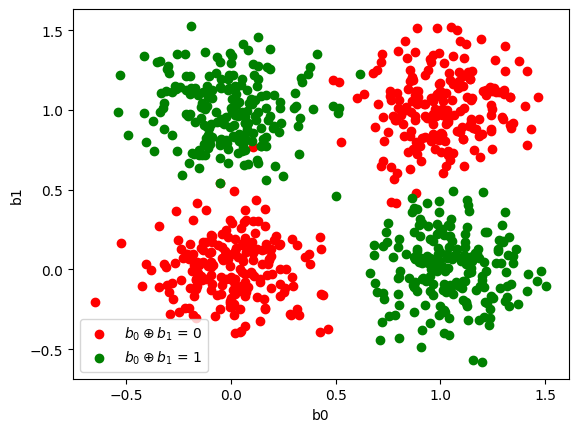

In [15]:
X, y = create_xor_dataset(num_samples_per_class=200, noise=0.2)

x0 = X[y == 0, :]
x1 = X[y == 1, :]

print(X.shape, y.shape)

plt.figure()
plt.scatter(x0[:, 0], x0[:, 1], c="red",label=r"$b_0 \oplus b_1$ = 0")
plt.scatter(x1[:, 0], x1[:, 1], c="green", label=r"$b_0 \oplus b_1$ = 1")
plt.xlabel("b0")
plt.ylabel("b1")
plt.legend()

### Slit into training and test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(640, 2) (160, 2) (640,) (160,)
(array([0., 1.]), array([313, 327], dtype=int64))
(array([0., 1.]), array([87, 73], dtype=int64))


### **Datasets & Dataloaders**

<div style="text-align: center;">
  <img src="imgs/ds_dl.png" alt="description" width="1200"/>
</div>

In PyTorch, `datasets` and `dataloaders` are integral components for efficiently managing and loading data during the training and evaluation of machine learning models. A dataset in PyTorch is essentially a container for your data, and a dataloader is responsible for efficiently iterating over the dataset in batches during training.

In [17]:
from torch.utils.data import TensorDataset, Dataset, DataLoader

train_dataset = TensorDataset(
    torch.FloatTensor(X_train), 
    torch.LongTensor(y_train)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test), 
    torch.LongTensor(y_test)
)

print("Train/Test elements: ", len(train_dataset), len(test_dataset))

Train/Test elements:  640 160


In [18]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # shuffle=True -> randomizes the ordering of elements after each epoch
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for i, batch in enumerate(test_loader):
    xi, yi = batch
    print(f"Batch {i}: ", xi.shape, yi.shape)

Batch 0:  torch.Size([64, 2]) torch.Size([64])
Batch 1:  torch.Size([64, 2]) torch.Size([64])
Batch 2:  torch.Size([32, 2]) torch.Size([32])


Custom datasets in PyTorch offer the flexibility to handle diverse data formats, apply specific data manipulations, and seamlessly integrate domain-specific features.

In [19]:
class CustomDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
        self.transform = transform

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        x = self.features[index] 
        y = self.labels[index]

        sample = (x, y)

        if self.transform:
            sample = self.transform(sample)

        return sample

In the above, the `CustomDataset` class is a subclass of `Dataset`, containing inputs `X` and outputs `y`. The `__getitem__` method in CustomDataset retrieves a sample, and the custom transformation is applied.

In [20]:
class CustomTransform:
    def __init__(self, coeff=-0.5, bias=1):
        self.coeff = coeff
        self.bias = bias

    def __call__(self, sample):
        x, y = sample
        
        x_ = x * self.coeff + self.bias
        y_ = nn.functional.one_hot(y, num_classes=2)

        return (x_, y_)

custom_test_dataset = CustomDataset(X_test, y_test, transform=CustomTransform())
custom_test_dataloader = DataLoader(custom_test_dataset, batch_size=batch_size, shuffle=True)

for i, batch in enumerate(custom_test_dataloader):
    xi, yi = batch
    print(f"Batch {i}: ", xi.shape, yi.shape)

Batch 0:  torch.Size([64, 2]) torch.Size([64, 2])
Batch 1:  torch.Size([64, 2]) torch.Size([64, 2])
Batch 2:  torch.Size([32, 2]) torch.Size([32, 2])


### **Defining a Neural Network**

In PyTorch, constructing models begins with defining a custom class that inherits from `nn.Module`. This class encapsulates the architecture by incorporating various layers, which can be either pre-defined PyTorch modules, like `nn.Linear`, or custom layers (see `CustomLinear` from `customs.py`). The `__init__` method of the class is used to initialize these layers, setting parameters such as input and output sizes. The core computation occurs in the `forward` method, where the forward pass through the network is specified, including the sequence of layers and any activation functions. 

In [21]:
from customs import CustomLinear

class FFN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, use_custom=False):
        super(FFN, self).__init__()

        if use_custom:
            linear_layer = lambda input_size, output_size: CustomLinear(input_size, output_size)
        else:
            linear_layer = lambda input_size, output_size: nn.Linear(input_size, output_size)

        self.fc1 = linear_layer(input_size, hidden_size)
        self.fc2 = linear_layer(hidden_size, hidden_size)
        self.fc3 = linear_layer(hidden_size, output_size)

    def forward(self, x):
        # x: tensor of shape (batch_size, number_of_features)
        h = self.fc1(x)
        h = self.fc2(h)
        y = self.fc3(h)

        return y

**Observation**: we'll not be using Softmax after the final layer! PyTorch's `torch.nn.CrossEntropyLoss()` expects **unnormalized output values**, i.e. logits.

### **Define Training/Test Step**

In [23]:
from tqdm import tqdm

def step(model, dataloader, optimizer, loss_fn, is_training=True, device='cuda'):
    # Set the model to training mode if it's a training step, otherwise to evaluation mode
    model.train() if is_training else model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in tqdm(dataloader, position=0, leave=True):
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        if is_training:
            outputs = model(inputs)
        else:
            with torch.no_grad():
                outputs = model(inputs)

        loss = loss_fn(outputs, labels) 

        # Backward pass and update if it's a training step
        if is_training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        # Cumulative loss for reporting
        total_loss += loss.item()

    # Calculate average loss and accuracy
    avg_loss = total_loss / len(dataloader)
    accuracy = correct_predictions / total_samples if total_samples > 0 else None

    return avg_loss, accuracy

### **Training Loop**

Set training configuration:

In [23]:
### Architecture-related hyperparams
input_size = 2
hidden_size = 32
output_size = 2
use_custom = False

### Training-related hyperparams
epochs = 30
learning_rate = 1e-3
print_frequency = 15

Define model, optimizer and loss:

In [24]:
model = FFN(input_size, hidden_size, output_size, use_custom=use_custom)

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate
)

loss = nn.CrossEntropyLoss()

We'll use the standard categorical-crossentropy loss for multi-class problems.

**Question**: What should you change in order to be able to use Binary-Crossentropy?

In [25]:
for e in range(1, epochs + 1):
    train_loss, train_acc = step(model, train_loader, optimizer, loss, device="cpu")

    if e % print_frequency == 0:
        with torch.no_grad():
            test_loss, test_acc = step(model, test_loader, optimizer, loss, is_training=False, device="cpu")
        print(f"Epoch {e}/{epochs}: train_loss={train_loss} train_acc={train_acc} test_loss={test_loss} test_acc={test_acc}")

100%|██████████| 3/3 [00:00<00:00, 1842.30it/s]


Epoch 15/30: train_loss=0.6930324673652649 train_acc=0.4859375 test_loss=0.6955564220746359 test_acc=0.5125


100%|██████████| 3/3 [00:00<00:00, 600.07it/s]

Epoch 30/30: train_loss=0.6937321424484253 train_acc=0.459375 test_loss=0.6978722016016642 test_acc=0.46875


### **Visualizing Decision Boundaries**

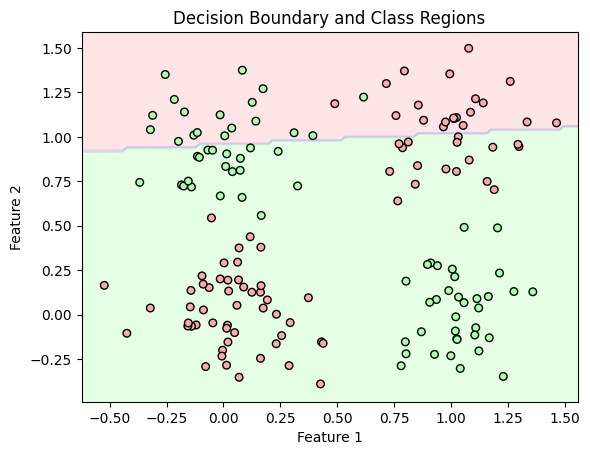

In [26]:
import utils
import importlib
importlib.reload(utils)
from utils import plot_decision_boundary

plot_decision_boundary(model, test_loader)

Why does this happen?

In [27]:
class FFN_non_linear(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, use_custom=False):
        super(FFN_non_linear, self).__init__()

        self.activation = nn.Tanh()
        if use_custom:
            linear_layer = lambda input_size, output_size: CustomLinear(input_size, output_size)
        else:
            linear_layer = lambda input_size, output_size: nn.Linear(input_size, output_size)

        self.fc1 = linear_layer(input_size, hidden_size)
        self.fc2 = linear_layer(hidden_size, hidden_size)
        self.fc3 = linear_layer(hidden_size, output_size)

    def forward(self, x):
        h = self.fc1(x)
        h = self.activation(h)
        h = self.fc2(h)
        h = self.activation(h)
        y = self.fc3(h)
        
        return y

In [28]:
model = FFN_non_linear(input_size, hidden_size, output_size, use_custom=use_custom)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss = nn.CrossEntropyLoss()

for e in range(1, epochs + 1):
    train_loss, train_acc = step(model, train_loader, optimizer, loss, device="cpu")

    if e % print_frequency == 0:
        test_loss, test_acc = step(model, test_loader, optimizer, loss, is_training=False, device="cpu")
        print(f"Epoch {e}/{epochs}: train_loss={train_loss} train_acc={train_acc} test_loss={test_loss} test_acc={test_acc}")

100%|██████████| 3/3 [00:00<00:00, 999.91it/s]


Epoch 15/30: train_loss=0.3835464745759964 train_acc=0.9875 test_loss=0.38186051448186237 test_acc=0.98125


100%|██████████| 3/3 [00:00<00:00, 541.69it/s]

Epoch 30/30: train_loss=0.09460584446787834 train_acc=0.9859375 test_loss=0.10670257608095805 test_acc=0.975


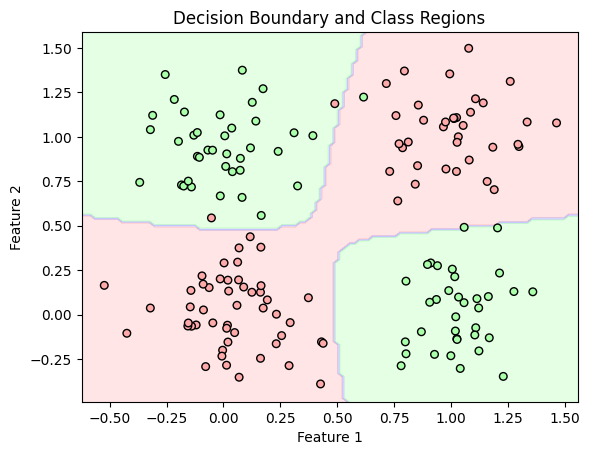

In [29]:
plot_decision_boundary(model, test_loader)

#### **Exercise: Play with the architecture**
Check, for different network depths and widths how the shape of the decision boundary changes, and draw some conclusions based on that. Look at how the decision boundary changes for the training data as well.

---

## Income / Socio-economic Prediction <a class="anchor" id="income"></a>

Predict income bracket from age, education, occupation, sex, etc, which naturally leads to discussions of bias and fairness.

### Load Data

In [2]:
import sklearn
from sklearn.datasets import fetch_openml

dataset = fetch_openml(name="adult", version=2, as_frame=True)
X = dataset.data.copy()
y = dataset.target.copy()


In [3]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States
4,18.0,NaN,103497.0,Some-college,10.0,Never-married,NaN,Own-child,White,Female,0.0,0.0,30.0,United-States


In [4]:
X.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
y.head()

0    <=50K
1    <=50K
2     >50K
3     >50K
4    <=50K
Name: class, dtype: category
Categories (2, object): ['>50K', '<=50K']

So, this is a binary classification task: predict whether the person earns more than 50K, or less.

### Pre-process data

Check for redundant columns: `education` and `education-num`.

Check for non0informative columns: `fnlwgt` corresponds to census sampling weight -> not predictive.

In [6]:
import numpy as np

X = X.drop(columns=["education", "fnlwgt"])
X = X.replace("?", np.nan)

Drop rows with missing values. There are several strategies for *filling* the empty slots, but we'll avoid them for simplicity and fairness.

In [7]:
mask = X.notna().all(axis=1)
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

Create labels from string descriptors: `>50k` -> `1`, `<=50k` -> `0`.

In [8]:
y = (y.str.strip().str.replace(".", "", regex=False) == ">50K").astype(int)

In [9]:
X.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25.0,Private,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States
1,38.0,Private,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States
2,28.0,Local-gov,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States
3,44.0,Private,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States
4,34.0,Private,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States


Create dummy clumns in order to encode the categorical variables. 

E.g. from column `occupation` there will be created a series of columns of the form `occupation_[OCCUPATION NAME]`, where `1.0` is placed in that column if the person initially had `occupation = [OUCCPATION NAME]`, and `0.0` otherwise.

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

NUMERIC_COLS = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CATEGORICAL_COLS = ["workclass", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

# Each category gets its own column, with 1.0 filled if this applies for the current record, and 0 otherwise.
X_cat = pd.get_dummies(X[CATEGORICAL_COLS], drop_first=False)

# Keep the numeric columns un-normalized! We didn't split into train and test yet!
X_num = pd.DataFrame(X[NUMERIC_COLS], columns=NUMERIC_COLS)

X_processed = pd.concat([X_num, X_cat], axis=1).astype(np.float32)

print(X_processed.head())        

    age  education-num  capital-gain  capital-loss  hours-per-week  \
0  25.0            7.0           0.0           0.0            40.0   
1  38.0            9.0           0.0           0.0            50.0   
2  28.0           12.0           0.0           0.0            40.0   
3  44.0           10.0        7688.0           0.0            40.0   
4  34.0            6.0           0.0           0.0            30.0   

   workclass_Private  workclass_Self-emp-not-inc  workclass_Self-emp-inc  \
0                1.0                         0.0                     0.0   
1                1.0                         0.0                     0.0   
2                0.0                         0.0                     0.0   
3                1.0                         0.0                     0.0   
4                1.0                         0.0                     0.0   

   workclass_Federal-gov  workclass_Local-gov  ...  native-country_Guatemala  \
0                    0.0                  

Train-test split.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)

**Scasle all records using only train split statistics, to avoid data leakage!** 

In [12]:
scaler = StandardScaler()

X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test[NUMERIC_COLS]  = scaler.transform(X_test[NUMERIC_COLS])

In [13]:
print(f"Train : {X_train.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

Train : 31,655
Test  : 13,567


In [14]:
column_names = list(X_train.columns)

X_train.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Private,workclass_Self-emp-not-inc,workclass_Self-emp-inc,workclass_Federal-gov,workclass_Local-gov,...,native-country_Guatemala,native-country_Nicaragua,native-country_Scotland,native-country_Thailand,native-country_Yugoslavia,native-country_El-Salvador,native-country_Trinadad&Tobago,native-country_Peru,native-country_Hong,native-country_Holand-Netherlands
25260,0.336395,1.510203,-0.148057,-0.2184,0.747279,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29047,1.770641,1.120307,13.081813,-0.2184,-0.084400,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28424,-1.324310,-0.049379,-0.148057,-0.2184,-0.084400,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37874,-0.493957,-1.219065,-0.148057,-0.2184,-0.084400,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11373,-0.946877,-0.049379,-0.148057,-0.2184,-0.084400,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Move to `torch.Tensor` objects.

In [15]:
import torch

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.LongTensor(y_train.values)

X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
y_test_t  = torch.LongTensor(y_test.values)

Check training labels distribution:

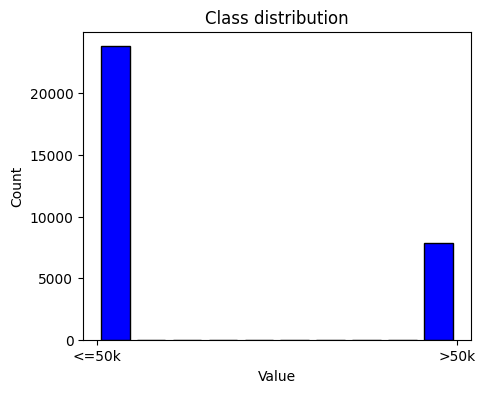

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.hist(y_train_t.numpy(), color='blue', edgecolor='black', rwidth=0.8)
plt.xticks([0,1], ["<=50k", ">50k"])
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Class distribution')
plt.show()

**Class imbalance** -> training on such distribution might lead to the network over-focusing on the majoritary class.

**Solution:** create dataloaders which will sample from the dataset with a higher frequency from the minoritary class. Check-out [Weighted Random Sampler](https://docs.pytorch.org/docs/stable/data.html#:~:text=class%20torch.utils.data.WeightedRandomSampler(weights%2C%20num_samples%2C%20replacement%3DTrue%2C%20generator%3DNone))

In [17]:
import torch
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

class_counts = torch.bincount(y_train_t)  
class_weights = 1. / class_counts.float()  
sample_weights = class_weights[y_train_t]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  
    replacement=True  
)

In [18]:
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=128, sampler=sampler)  
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

### Build the neural network

In [19]:
import torch.nn as nn

class FFN_2(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        
        if isinstance(hidden_sizes, int):
            hidden_sizes = [hidden_sizes]
        
        layers = []
        in_size = input_size
        
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            in_size = h
        
        layers.append(nn.Linear(in_size, output_size))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [20]:
input_size = X_train_t.shape[-1]
output_size = 2
hidden_sizes = [128, 64, 32]

epochs = 10
learning_rate = 1e-2
print_frequency = 2

In [21]:
model = FFN_2(input_size, hidden_sizes, output_size)

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate,
)

loss = nn.CrossEntropyLoss()

### Train

In [24]:
for e in range(1, epochs + 1):
    train_loss, train_acc = step(model, train_loader, optimizer, loss, device="cpu")

    if e % print_frequency == 0:
        with torch.no_grad():
            test_loss, test_acc = step(model, test_loader, optimizer, loss, is_training=False, device="cpu")
        print(f"Epoch {e}/{epochs}: train_loss={train_loss} train_acc={train_acc} test_loss={test_loss} test_acc={test_acc}")

100%|██████████| 106/106 [00:00<00:00, 405.51it/s]


Epoch 2/10: train_loss=0.37565066184728374 train_acc=0.8284631179908387 test_loss=0.3920313294203776 test_acc=0.7974496941107098


100%|██████████| 106/106 [00:00<00:00, 387.54it/s]


Epoch 4/10: train_loss=0.36007936857640743 train_acc=0.8311799083873006 test_loss=0.4111816894333318 test_acc=0.7929534900862387


100%|██████████| 106/106 [00:00<00:00, 423.85it/s]


Epoch 6/10: train_loss=0.3553220128580447 train_acc=0.8336439740957194 test_loss=0.3900888829298739 test_acc=0.8138866366919731


100%|██████████| 106/106 [00:00<00:00, 462.37it/s]


Epoch 8/10: train_loss=0.34929975326503476 train_acc=0.8360132680461223 test_loss=0.3713534342230491 test_acc=0.8178668828775706


100%|██████████| 106/106 [00:00<00:00, 377.26it/s]

Epoch 10/10: train_loss=0.3382677883510628 train_acc=0.8404359500868741 test_loss=0.3798308867328572 test_acc=0.8026092724994471


### Evaluate Model

In [25]:
y_true = []
y_pred = []
model.eval()

for batch in test_loader:
    x, y = batch
    y_ = model(x).argmax(dim=-1)
    
    y_true.extend(y.tolist())
    y_pred.extend(y_.tolist())

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

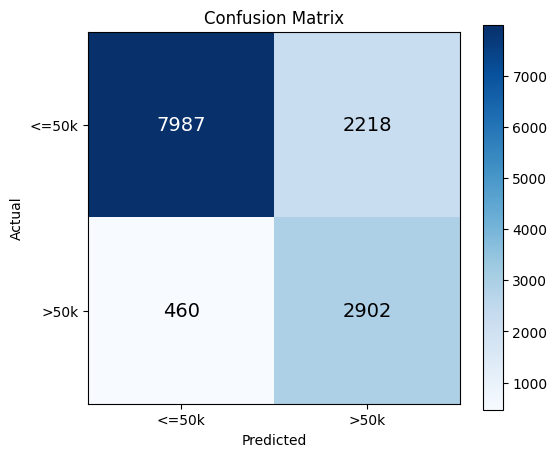

In [27]:
import matplotlib.pyplot as plt

labels = ['<=50k', '>50k']

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the matrix using imshow
cax = ax.imshow(cm, cmap='Blues')

# Add colorbar
fig.colorbar(cax)

# Set tick labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Label axes
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

# Annotate each cell with the numeric value
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.show()

### Bias Analysis

We'll now check if the model learned some bias inherent to the data.

In [28]:
feature_importance = None

for batch in test_loader:
    x, y = batch
    x = x.clone().detach().requires_grad_(True)
    y_ = model(x)
    
    loss_ = loss(y_, y)
    loss_.backward()
    
    if feature_importance is None:
        feature_importance = (x.grad**2).mean(dim=0)  # shape (88,)
    else:
        feature_importance += (x.grad**2).mean(dim=0)

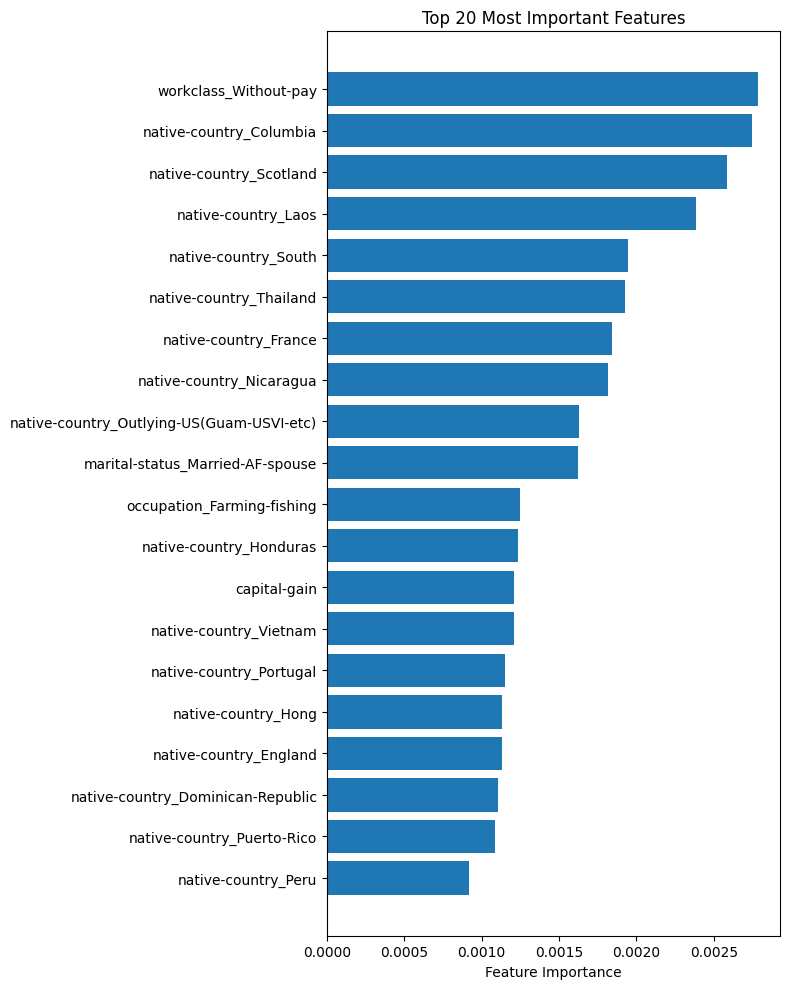

In [29]:
feature_importance = np.array(feature_importance)

indices = np.argsort(feature_importance)[::-1]
sorted_importances = feature_importance[indices]
sorted_names = [column_names[i] for i in indices]

k = 20
sorted_importances = sorted_importances[:k]
sorted_names = sorted_names[:k]

plt.figure(figsize=(8, 10))
plt.barh(sorted_names[::-1], sorted_importances[::-1])
plt.xlabel("Feature Importance")
plt.title(f"Top {k} Most Important Features")
plt.tight_layout()
plt.show()

---

#### Is there Gender Bias?

In [43]:
for i, cm in enumerate(column_names):
    if "sex" in cm:
        print(i, cm)


45 sex_Female
46 sex_Male


In [44]:
mask_female = X_test_t[:, 45] == 1
mask_male   = X_test_t[:, 46] == 1

In [56]:
def compute_metrics(mask, y_true, y_pred):
    yt = y_true[mask]
    yp = y_pred[mask]

    acc = (yt == yp).mean()

    tp = ((yp == 1) & (yt == 1)).sum()
    fp = ((yp == 1) & (yt == 0)).sum()
    fn = ((yp == 0) & (yt == 1)).sum()
    tn = ((yp == 0) & (yt == 0)).sum()

    fpr = fp / (fp + tn + 1e-8)
    fnr = fn / (fn + tp + 1e-8)
    
    pos_rate = yp.mean()
    true_pos_rate = yt.mean()
    err = (pos_rate - true_pos_rate) / true_pos_rate

    return {
        "accuracy": acc.item(),
        "FPR": fpr.item(),
        "FNR": fnr.item(),
        "predicted_positive_rate": pos_rate.item(),
        "true_positive_rate": true_pos_rate.item(),
        "relative_error_positive_rate (%)": err.item() * 100
    }

In [57]:
female_results = compute_metrics(mask_female.numpy(), np.array(y_true), np.array(y_pred))
male_results = compute_metrics(mask_male.numpy(), np.array(y_true), np.array(y_pred))

df = pd.DataFrame({
    "Female": female_results,
    "Male": male_results
}).T  

df

,accuracy,FPR,FNR,predicted_positive_rate,true_positive_rate,relative_error_positive_rate (%)
Female,0.906935,0.071575,0.251418,0.152473,0.119494,27.599244
Male,0.752079,0.307436,0.115425,0.486324,0.309956,56.900812


- Relative error Male >> Relative Error Female -> stronger bias towards predicting high-income for Male subjects
- FPR Male >> FPR Female -> high-income predictions for Male subjects are, on average, more falsely predicted
- FNR Female >> FNR Male -> Female subject are missed twice as often when they should be predicted positive

---

#### Is there Race Bias?

In [58]:
for i, cm in enumerate(column_names):
    if "race" in cm:
        print(i, cm)


40 race_White
41 race_Asian-Pac-Islander
42 race_Amer-Indian-Eskimo
43 race_Other
44 race_Black


In [59]:
race_columns = {
    40: "White",
    41: "Asian-Pac-Islander",
    42: "Amer-Indian-Eskimo",
    43: "Other",
    44: "Black"
}

In [64]:
race_results = {}

for idx, name in race_columns.items():
    mask = X_test_t[:, idx] == 1
    race_results[name] = compute_metrics(mask.numpy(), np.array(y_true), np.array(y_pred))
    
race_df = pd.DataFrame(race_results).T

race_df

,accuracy,FPR,FNR,predicted_positive_rate,true_positive_rate,relative_error_positive_rate (%)
White,0.790128,0.238471,0.129412,0.404233,0.262233,54.150327
Asian-Pac-Islander,0.813776,0.217993,0.097087,0.397959,0.262755,51.456311
Amer-Indian-Eskimo,0.834646,0.180180,0.062500,0.275591,0.125984,118.750000
Other,0.903509,0.067961,0.363636,0.122807,0.096491,27.272727
Black,0.901976,0.068618,0.284884,0.156522,0.135968,15.116279


---

#### Is there Occupation Bias?

In [73]:
occ_columns = {}

for i, cm in enumerate(column_names):
    if "occupation" in cm:
        print(i, cm)
        occ_columns[i] = cm

20 occupation_Tech-support
21 occupation_Craft-repair
22 occupation_Other-service
23 occupation_Sales
24 occupation_Exec-managerial
25 occupation_Prof-specialty
26 occupation_Handlers-cleaners
27 occupation_Machine-op-inspct
28 occupation_Adm-clerical
29 occupation_Farming-fishing
30 occupation_Transport-moving
31 occupation_Priv-house-serv
32 occupation_Protective-serv
33 occupation_Armed-Forces


In [74]:
occ_results = {}

for idx, name in occ_columns.items():
    mask = X_test_t[:, idx] == 1
    occ_results[name] = compute_metrics(mask.numpy(), np.array(y_true), np.array(y_pred))
    
occ_df = pd.DataFrame(occ_results).T
occ_df = occ_df.sort_values('relative_error_positive_rate (%)', ascending=False)

occ_df

,accuracy,FPR,FNR,predicted_positive_rate,true_positive_rate,relative_error_positive_rate (%)
occupation_Handlers-cleaners,0.882911,0.102178,0.371429,0.131329,0.055380,137.142857
occupation_Priv-house-serv,0.987952,0.012195,0.000000,0.024096,0.012048,100.000000
occupation_Transport-moving,0.709632,0.317117,0.192053,0.422096,0.213881,97.350993
occupation_Machine-op-inspct,0.823529,0.164238,0.258929,0.238754,0.129181,84.821429
occupation_Adm-clerical,0.861111,0.136872,0.150000,0.246454,0.153664,60.384615
occupation_Protective-serv,0.732673,0.367347,0.084112,0.561056,0.353135,58.878505
occupation_Craft-repair,0.744365,0.250000,0.274699,0.358439,0.228147,57.108434
occupation_Sales,0.804583,0.230500,0.102326,0.413113,0.273711,50.930233
occupation_Other-service,0.943750,0.038961,0.500000,0.056250,0.037500,50.000000
occupation_Tech-support,0.789934,0.246154,0.121212,0.428884,0.288840,48.484848


---

**Some Bias Mitigation Techniques:**
- *Removing Sensitive Attributes*: this, however, might cause the model to be less powerful
- [Fairness Regularization](https://proceedings.mlr.press/v54/zafar17a/zafar17a.pdf)
- [Group Distributionally Robust Optimization (GDRO)](https://arxiv.org/pdf/1911.08731)

---

## 📓 Homework (20 pts, teams of max. 2) - Bias Assessment and Mitigation

In this homework, you will investigate bias in neural networks for a classification application of your choice. 

Steps:
1. **Problem Formulation** `(5 pts)`:
 - Dataset selection
❗ **You should choose a dataset different from the one used in this Lab**.
 - Model definition
 - Pre-processing steps
 - Training & Evaluation
2. **Bias Assessment** `(7.5 pts)`:
 - Discuss and define what bias means in your case `(2.5 pts)`
 - You should experiment with at least 2 methods for assessing the bias, tailored to your dataset of choice. `(2 x 2.5 pts)`
3. **Bias Mitigation** `(7.5 pts)`: 
 - You should experiment with at least 2 methods aimed at removing bias `(2 x 2.5 pts)`, and measure their effectiveness.
 - Discuss limitations of your chosen mitigation methods. `(2.5 pts)`

No project report is required. Your submission will consist in:
1. `.zip` or a public Github containing the source code. You can include all your homework in a single Jupyter notebook, provided that you include any necessary dependencies.
2. A `5-minute` presentation in `.pdf` format, which will be presented in the last week of this course. The presentation should be made similar to [this Overleaf template.](https://www.overleaf.com/latex/templates/cnu-beamer/ftpfhcwstgpy), and should include:
   - A brief description of your chosen task: objective, dataset, model, training setup
   - Description of your Bias Assessment methodology
   - Bias Evaluation
   - Description of your Bias Mitigation methodology
   - Bias Mitigation results